# 경기도 여행 플래너 RAG 성능 평가 (RAGAS)

> **커널 선택:** VS Code 우상단 → `base` (Python 3.13, `/opt/anaconda3/bin/python`) 선택

| 지표 | 설명 | Ground Truth 필요 |
|------|------|:---:|
| **Faithfulness** | 답변이 검색 문맥에 근거하는가 (환각 방지) | ✗ |
| **Answer Relevancy** | 답변이 질문과 얼마나 관련 있는가 | ✗ |
| **Context Precision** | 관련 문맥이 검색 결과 상위에 있는가 | ✓ |
| **Context Recall** | 정답에 필요한 정보가 검색 결과에 포함됐는가 | ✓ |

> 점수 범위: 0~1 | 0.9↑ 우수 / 0.7~0.89 양호 / 0.5~0.69 개선 필요 / 0.5↓ 요주의

## 0. 패키지 설치 (처음 한 번만)

In [1]:
# 필요 시 주석 해제 후 실행
# import sys
# !{sys.executable} -m pip install ragas datasets langchain langchain-openai langchain-chroma chromadb python-dotenv pandas matplotlib

## 1. Import & 환경 설정

In [52]:
import os, sys, warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()                        # .env → OPENAI_API_KEY 자동 로드
load_dotenv("KAKAO_REST_API_KEY.env")

import ragas
import langchain
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from datasets import Dataset
from ragas import evaluate

# ragas 0.4.x: ragas.metrics 의 싱글톤 사용 (collections 아님)
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('font', family='AppleGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

print(f"Python   : {sys.version.split()[0]}")
print(f"ragas    : {ragas.__version__}")
print(f"langchain: {langchain.__version__}")
print(f"OPENAI_API_KEY: {'✓ 설정됨' if os.getenv('OPENAI_API_KEY') else '✗ .env 파일 확인 필요'}")

Python   : 3.13.9
ragas    : 0.4.3
langchain: 1.2.15
OPENAI_API_KEY: ✓ 설정됨


## 2. RAGAS 평가용 LLM / 임베딩 설정

In [53]:
ragas_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini", temperature=0))
ragas_emb = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

faithfulness.llm        = ragas_llm
answer_relevancy.llm    = ragas_llm
answer_relevancy.embeddings = ragas_emb
context_precision.llm   = ragas_llm
context_recall.llm      = ragas_llm

METRICS = [faithfulness, answer_relevancy, context_precision, context_recall]
METRIC_COLS = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

print("RAGAS LLM / 임베딩 설정 완료 (gpt-4o-mini)")

RAGAS LLM / 임베딩 설정 완료 (gpt-4o-mini)


## 3. Ground Truth 10개 정의

`data/여행가이드.pdf` 기반으로 직접 작성한 모범 정답입니다.

- 사실 질문 3개 + 비교/설명 질문 4개 + 추론 질문 3개

In [54]:
ground_truth_data = [
    # ── 사실 질문 ──
    {
        "question":     "광명동굴의 총 길이와 총 깊이는 얼마인가요?",
        "ground_truth": "광명동굴의 총 길이는 7.8km(개방 2km)이고, 총 깊이는 275m입니다."
    },
    {
        "question":     "화담숲은 서울에서 얼마나 걸리나요?",
        "ground_truth": "화담숲은 서울에서 약 40분 거리에 있는 생태수목원입니다."
    },
    {
        "question":     "가평 시티투어 예약 전화번호는 무엇인가요?",
        "ground_truth": "가평 시티투어 관광지 순환버스 예약 전화번호는 031-582-2308 또는 031-585-7242입니다."
    },
    # ── 비교/설명 질문 ──
    {
        "question":     "경기도 구리시의 유네스코 세계문화유산은 무엇인가요?",
        "ground_truth": "구리시의 유네스코 세계문화유산은 동구릉입니다."
    },
    {
        "question":     "남한산성이 유네스코 세계문화유산인 이유를 알려주세요.",
        "ground_truth": "남한산성은 유네스코 세계문화유산으로 지정된 역사적 유적지이며, 행궁과 만해기념관 등 역사 문화 시설을 갖추고 있습니다."
    },
    {
        "question":     "경기 서북부 시티투어 코스 종류는 어떤 것이 있나요?",
        "ground_truth": "경기 서북부 시티투어 코스는 고양·파주 역사자연, 파주·김포 안보예술, 김포·고양 생태문화 등이 있습니다."
    },
    {
        "question":     "화성시에서 공룡 화석을 볼 수 있는 곳은 어디인가요?",
        "ground_truth": "화성시 공룡알화석산지에서 공룡알 화석 200여 개를 볼 수 있으며, 우리나라 최초 뿔공룡 코리아케라톱스 화성엔시스도 만날 수 있습니다."
    },
    # ── 추론 질문 ──
    {
        "question":     "광명동굴은 원래 어떤 용도로 사용되었나요?",
        "ground_truth": "광명동굴은 1912년 일제가 자원수탈을 목적으로 개발했고, 1972년 폐광 후 약 40년간 새우젓 창고로 사용되다가 2011년 광명시가 매입해 관광명소로 탈바꿈했습니다."
    },
    {
        "question":     "군포시 도심 여행 추천 코스를 알려주세요.",
        "ground_truth": "군포 도심 여행 코스는 산본로데오거리 → 산본시장 → 철쭉동산 → 초막골 생태공원 → 반월호수 공원 순서로 이어집니다."
    },
    {
        "question":     "화성시의 대표 축제는 무엇인가요?",
        "ground_truth": "화성시의 대표 축제로는 화성뱃놀이축제와 정조효문화제가 있습니다."
    },
]

print(f"Ground Truth {len(ground_truth_data)}개 준비 완료")
for i, item in enumerate(ground_truth_data, 1):
    print(f"  Q{i:02d}: {item['question']}")

Ground Truth 10개 준비 완료
  Q01: 광명동굴의 총 길이와 총 깊이는 얼마인가요?
  Q02: 화담숲은 서울에서 얼마나 걸리나요?
  Q03: 가평 시티투어 예약 전화번호는 무엇인가요?
  Q04: 경기도 구리시의 유네스코 세계문화유산은 무엇인가요?
  Q05: 남한산성이 유네스코 세계문화유산인 이유를 알려주세요.
  Q06: 경기 서북부 시티투어 코스 종류는 어떤 것이 있나요?
  Q07: 화성시에서 공룡 화석을 볼 수 있는 곳은 어디인가요?
  Q08: 광명동굴은 원래 어떤 용도로 사용되었나요?
  Q09: 군포시 도심 여행 추천 코스를 알려주세요.
  Q10: 화성시의 대표 축제는 무엇인가요?


## 4. 벡터스토어 (ChromaDB) 로드

In [55]:
import re

DB_DIR               = "chroma_db_travel"
SELF_RAG_RETRIEVAL_K = 6   # app.py와 동일
SELF_RAG_CONTEXT_K   = 5   # app.py와 동일

embeddings  = OpenAIEmbeddings()
vectorstore = Chroma(persist_directory=DB_DIR, embedding_function=embeddings)

doc_count = vectorstore._collection.count()
print(f"벡터스토어 로딩 완료! (저장된 청크 수: {doc_count}개)")
print(f"app.py 설정 반영 → RETRIEVAL_K={SELF_RAG_RETRIEVAL_K}, CONTEXT_K={SELF_RAG_CONTEXT_K}")


def grade_retrieved_docs(llm, question, docs):
    """app.py grade_retrieved_docs와 동일한 Self-RAG 관련성 평가 로직"""
    if not docs:
        return []

    grade_prompt = ChatPromptTemplate.from_template(
        """사용자 질문에 답하는 데 각 문서가 직접적으로 도움이 되는지 평가하세요.

[사용자 질문]
{question}

[검색 문서]
{documents}

각 줄을 반드시 아래 형식으로만 출력하세요.
1. YES
2. NO
"""
    )
    chain = grade_prompt | llm | StrOutputParser()

    doc_texts = "\n\n".join(
        f"[문서 {i+1}]\n{doc.page_content[:400]}"
        for i, doc in enumerate(docs)
    )
    try:
        raw = chain.invoke({"question": question, "documents": doc_texts})
        grades = {}
        for m in re.finditer(r"(\d+)\s*[\.\):\-]\s*(YES|NO|예|아니오)", raw, re.IGNORECASE):
            idx = int(m.group(1)) - 1
            grades[idx] = m.group(2).lower() in ["yes", "예"]
        relevant = [doc for i, doc in enumerate(docs) if grades.get(i, False)]
        return relevant[:SELF_RAG_CONTEXT_K] if relevant else docs[:SELF_RAG_CONTEXT_K]
    except Exception:
        return docs[:SELF_RAG_CONTEXT_K]

벡터스토어 로딩 완료! (저장된 청크 수: 128개)
app.py 설정 반영 → RETRIEVAL_K=6, CONTEXT_K=5


## 5. RAG 체인 구성

In [56]:
# app.py와 동일한 LLM 설정
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

# app.py 메인 프롬프트의 핵심 구조 그대로 적용
prompt = ChatPromptTemplate.from_template("""\
당신은 경기도 여행 전문가입니다.

⚠️ [핵심 원칙 - 충실도 준수]
- 답변은 반드시 아래 [Context - 문서 데이터베이스]에 있는 내용만 활용하세요.
- 문서에 없는 장소명, 영업시간, 입장료, 사실을 절대 추론하거나 지어내지 마세요.
- 확인되지 않은 정보는 반드시 "해당 정보는 자료에 없어서 정확히 알려드리기 어렵습니다"라고 명시하세요.
- 문맥 밖의 정보를 사실처럼 서술하면 사용자에게 심각한 해가 됩니다.

[답변 형식 가이드라인]
- 질문에 직접 답하는 내용을 먼저 제시하세요.
- 문서에 없는 정보는 "확인 필요"로 표시하세요.
- 사용자가 묻지 않은 정보를 과도하게 나열하지 마세요.

[Context - 문서 데이터베이스]
{context}

질문: {question}

답변:""")

chain = prompt | llm | StrOutputParser()
print("RAG 체인 구성 완료!")
print("→ app.py 프롬프트(충실도 원칙 + 답변 가이드라인) / temperature=0.3 적용")

RAG 체인 구성 완료!
→ app.py 프롬프트(충실도 원칙 + 답변 가이드라인) / temperature=0.3 적용


## 6. RAG 답변 & 문맥 수집

In [60]:
questions, answers, contexts, ground_truths = [], [], [], []

print("RAG 답변 생성 중 (app.py Self-RAG 로직 적용)...\n")
for i, item in enumerate(ground_truth_data, 1):
    q  = item["question"]
    gt = item["ground_truth"]

    # 1단계: 후보 문서 검색 (app.py SELF_RAG_RETRIEVAL_K=6)
    retriever      = vectorstore.as_retriever(search_kwargs={"k": SELF_RAG_RETRIEVAL_K})
    candidate_docs = retriever.invoke(q)

    # 2단계: Self-RAG 관련성 평가 → 관련 문서만 필터링 (app.py grade_retrieved_docs)
    relevant_docs  = grade_retrieved_docs(llm, q, candidate_docs)

    context_text = "\n\n".join(d.page_content for d in relevant_docs)
    context_list = [d.page_content for d in relevant_docs]

    answer = chain.invoke({"context": context_text, "question": q})

    questions.append(q)
    answers.append(answer)
    contexts.append(context_list)
    ground_truths.append(gt)

    print(f"  Q{i:02d} ✓  {q}")
    print(f"       후보 {len(candidate_docs)}개 → Self-RAG 필터 후 {len(relevant_docs)}개")
    print(f"       → {answer[:80].strip()}...\n")

print("답변 수집 완료!")

RAG 답변 생성 중 (app.py Self-RAG 로직 적용)...

  Q01 ✓  광명동굴의 총 길이와 총 깊이는 얼마인가요?
       후보 6개 → Self-RAG 필터 후 2개
       → 광명동굴의 총 길이는 7.8km(개방 2km)이며, 총 깊이는 275m입니다....

  Q02 ✓  화담숲은 서울에서 얼마나 걸리나요?
       후보 6개 → Self-RAG 필터 후 1개
       → 화담숲은 서울에서 40분 거리에 위치해 있습니다....

  Q03 ✓  가평 시티투어 예약 전화번호는 무엇인가요?
       후보 6개 → Self-RAG 필터 후 2개
       → 가평 시티투어 예약 전화번호는 031-582-2308 또는 031-585-7242입니다....

  Q04 ✓  경기도 구리시의 유네스코 세계문화유산은 무엇인가요?
       후보 6개 → Self-RAG 필터 후 2개
       → 경기도 구리시의 유네스코 세계문화유산은 동구릉입니다. 동구릉은 2009년 6월에 유네스코에서 세계문화유산으로 등재된 조선왕릉의 능침지 중 최대...

  Q05 ✓  남한산성이 유네스코 세계문화유산인 이유를 알려주세요.
       후보 6개 → Self-RAG 필터 후 2개
       → 남한산성이 유네스코 세계문화유산으로 등재된 이유는 조선 시대의 군사행정 도시로서의 중요성과 역사적 가치 때문입니다. 남한산성은 한양을 방어하는...

  Q06 ✓  경기 서북부 시티투어 코스 종류는 어떤 것이 있나요?
       후보 6개 → Self-RAG 필터 후 2개
       → 경기 서북부 시티투어 코스에는 다음과 같은 종류가 있습니다:

1. **고양코스**: 행주산성의 이야기와 2021년 람사르습지로 지정된 장항습지...

  Q07 ✓  화성시에서 공룡 화석을 볼 수 있는 곳은 어디인가요?
       후보 6개 → Self-RAG 필터 후 1개
       → 화성시에서 공룡 화석을 볼 수 있는 곳은 "화성 공룡알화석지"입

## 7. RAGAS 평가 실행

> ⏳ LLM API 반복 호출로 1~3분 소요됩니다.

In [61]:
dataset = Dataset.from_dict({
    "question":     questions,
    "answer":       answers,
    "contexts":     contexts,
    "ground_truth": ground_truths,
})

print("RAGAS 평가 실행 중...")
result = evaluate(dataset, metrics=METRICS)
print("\n평가 완료!")
print(result)

RAGAS 평가 실행 중...


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.



평가 완료!
{'faithfulness': 0.8603, 'answer_relevancy': 0.8626, 'context_precision': 0.9000, 'context_recall': 0.9000}


## 8. 질문별 상세 점수

In [62]:
df = result.to_pandas()
df.insert(0, "질문", questions)

display_df = df[["질문"] + METRIC_COLS].copy()
display_df[METRIC_COLS] = display_df[METRIC_COLS].round(3)
display_df

,질문,faithfulness,answer_relevancy,context_precision,context_recall
0,광명동굴의 총 길이와 총 깊이는 얼마인가요?,1.000,0.894,1.0,1.0
1,화담숲은 서울에서 얼마나 걸리나요?,1.000,0.867,1.0,1.0
2,가평 시티투어 예약 전화번호는 무엇인가요?,1.000,0.869,0.5,1.0
3,경기도 구리시의 유네스코 세계문화유산은 무엇인가요?,1.000,0.851,1.0,1.0
4,남한산성이 유네스코 세계문화유산인 이유를 알려주세요.,0.714,0.848,1.0,0.0
5,경기 서북부 시티투어 코스 종류는 어떤 것이 있나요?,0.889,0.865,1.0,1.0
6,화성시에서 공룡 화석을 볼 수 있는 곳은 어디인가요?,1.000,0.858,1.0,1.0
7,광명동굴은 원래 어떤 용도로 사용되었나요?,1.000,0.867,1.0,1.0
8,군포시 도심 여행 추천 코스를 알려주세요.,1.000,0.850,1.0,1.0
9,화성시의 대표 축제는 무엇인가요?,0.000,0.857,0.5,1.0


## 9. 팀 평균 점수 & 등급 판정

In [63]:
mean_scores = df[METRIC_COLS].mean()

def grade(s):
    if s >= 0.9: return "우수"
    if s >= 0.7: return "양호"
    if s >= 0.5: return "개선 필요"
    return "요주의"

LABELS = {
    "faithfulness":      "Faithfulness    (충실도)",
    "answer_relevancy":  "Answer Relevancy (답변 관련성)",
    "context_precision": "Context Precision (문맥 정밀도)",
    "context_recall":    "Context Recall   (문맥 재현율)",
}

print("=" * 58)
print("  경기도 여행 플래너 RAG 성능 평가 결과")
print("=" * 58)
for col, label in LABELS.items():
    s = mean_scores[col]
    print(f"  {label}: {s:.3f}  [{grade(s)}]")
print("-" * 58)
overall = mean_scores.mean()
print(f"  {'종합 평균':<40}: {overall:.3f}  [{grade(overall)}]")
print("=" * 58)

  경기도 여행 플래너 RAG 성능 평가 결과
  Faithfulness    (충실도): 0.860  [양호]
  Answer Relevancy (답변 관련성): 0.863  [양호]
  Context Precision (문맥 정밀도): 0.900  [양호]
  Context Recall   (문맥 재현율): 0.900  [우수]
----------------------------------------------------------
  종합 평균                                   : 0.881  [양호]


## 10. 막대 그래프 시각화

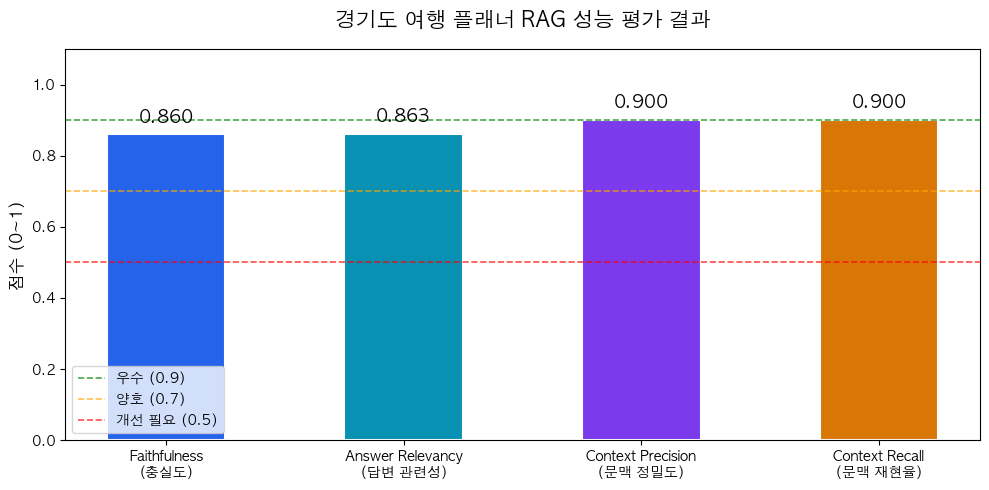

그래프 저장 완료 → ragas_result.png


In [64]:
korean_labels = [
    "Faithfulness\n(충실도)",
    "Answer Relevancy\n(답변 관련성)",
    "Context Precision\n(문맥 정밀도)",
    "Context Recall\n(문맥 재현율)",
]
colors = ["#2563EB", "#0891B2", "#7C3AED", "#D97706"]
values = [mean_scores[c] for c in METRIC_COLS]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(korean_labels, values, color=colors, width=0.5, edgecolor="white", linewidth=1.5)

ax.set_ylim(0, 1.1)
ax.set_ylabel("점수 (0~1)", fontsize=12)
ax.set_title("경기도 여행 플래너 RAG 성능 평가 결과", fontsize=15, fontweight="bold", pad=16)
ax.axhline(0.9, color="green",  linestyle="--", linewidth=1.2, alpha=0.7, label="우수 (0.9)")
ax.axhline(0.7, color="orange", linestyle="--", linewidth=1.2, alpha=0.7, label="양호 (0.7)")
ax.axhline(0.5, color="red",    linestyle="--", linewidth=1.2, alpha=0.7, label="개선 필요 (0.5)")

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=13, fontweight="bold"
    )

ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("ragas_result.png", dpi=150)
plt.show()
print("그래프 저장 완료 → ragas_result.png")

## 11. 낮은 지표 개선 방향

In [65]:
IMPROVEMENTS = {
    "faithfulness":      "프롬프트에 '반드시 문맥만 활용' 명시, 환각 방지 지시 추가",
    "answer_relevancy":  "시스템 프롬프트 개선, 답변 형식 & 길이 가이드라인 추가",
    "context_precision": "청크 크기 줄이기, 임베딩 모델 교체, Top-K 수 조정",
    "context_recall":    "청크 오버랩 늘리기, 더 많은 청크(K) 검색하도록 변경",
}

needs = [(c, mean_scores[c]) for c in METRIC_COLS if mean_scores[c] < 0.9]

if not needs:
    print("모든 지표가 우수(0.9 이상)입니다!")
else:
    print("개선이 필요한 지표:\n")
    for col, s in sorted(needs, key=lambda x: x[1]):
        print(f"  [{grade(s)}] {LABELS[col]}: {s:.3f}")
        print(f"    → {IMPROVEMENTS[col]}\n")

개선이 필요한 지표:

  [양호] Faithfulness    (충실도): 0.860
    → 프롬프트에 '반드시 문맥만 활용' 명시, 환각 방지 지시 추가

  [양호] Answer Relevancy (답변 관련성): 0.863
    → 시스템 프롬프트 개선, 답변 형식 & 길이 가이드라인 추가

  [양호] Context Precision (문맥 정밀도): 0.900
    → 청크 크기 줄이기, 임베딩 모델 교체, Top-K 수 조정



## 12. CSV 저장

In [66]:
save_df = df[["질문"] + METRIC_COLS].copy()
save_df[METRIC_COLS] = save_df[METRIC_COLS].round(4)
save_df.to_csv("ragas_result.csv", index=False, encoding="utf-8-sig")

print("저장 완료 → ragas_result.csv")
save_df

저장 완료 → ragas_result.csv


,질문,faithfulness,answer_relevancy,context_precision,context_recall
0,광명동굴의 총 길이와 총 깊이는 얼마인가요?,1.0000,0.8940,1.0,1.0
1,화담숲은 서울에서 얼마나 걸리나요?,1.0000,0.8669,1.0,1.0
2,가평 시티투어 예약 전화번호는 무엇인가요?,1.0000,0.8693,0.5,1.0
3,경기도 구리시의 유네스코 세계문화유산은 무엇인가요?,1.0000,0.8510,1.0,1.0
4,남한산성이 유네스코 세계문화유산인 이유를 알려주세요.,0.7143,0.8485,1.0,0.0
5,경기 서북부 시티투어 코스 종류는 어떤 것이 있나요?,0.8889,0.8647,1.0,1.0
6,화성시에서 공룡 화석을 볼 수 있는 곳은 어디인가요?,1.0000,0.8577,1.0,1.0
7,광명동굴은 원래 어떤 용도로 사용되었나요?,1.0000,0.8667,1.0,1.0
8,군포시 도심 여행 추천 코스를 알려주세요.,1.0000,0.8500,1.0,1.0
9,화성시의 대표 축제는 무엇인가요?,0.0000,0.8573,0.5,1.0
